# Cross-Correlation Implementation from Scratch

### 🎯 Objective
To understand the mathematical relationship between **Convolution** and **Correlation** by implementing the logic manually without using built-in libraries.

### 🧠 Key Concept
Cross-correlation measures the similarity between two signals as a function of the displacement of one relative to the other.
Formula: $r_{xy}[l] = \sum_{n=-\infty}^{\infty} x[n] y[n-l]$

In DSP, this is equivalent to the **Convolution** of $x[n]$ and the **Time-Reversed** version of $y[n]$:
$$r_{xy}(n) = x(n) * y(-n)$$

### 🛠 Description
This notebook demonstrates:
1.  **Custom Functions:** Implementation of `sigfold` (Time Reversal) and `convf` (Convolution).
2.  **Manual Calculation:** Computing correlation by convolving $x[n]$ with $y[-n]$.
3.  **Verification:** Comparing the manual result with NumPy's `np.correlate(mode='full')` to validate accuracy.

indices n: [0 1 2 3 4 5 6]
y(n): [12.  0.  5.  0.  2.  3.  5.]
indices m: [0 1 2 3 4 5 6]

Correlation (manual) length: 13
lags (full): [-6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6]
R_xy (manual) = [10 21 18 14 15 52 75 70 22 47 25 84 60]

np.correlate verification equal?: True
np.correlate result = [10 21 18 14 15 52 75 70 22 47 25 84 60]

Peak correlation = 84.0 at lag = 5 (index 11)


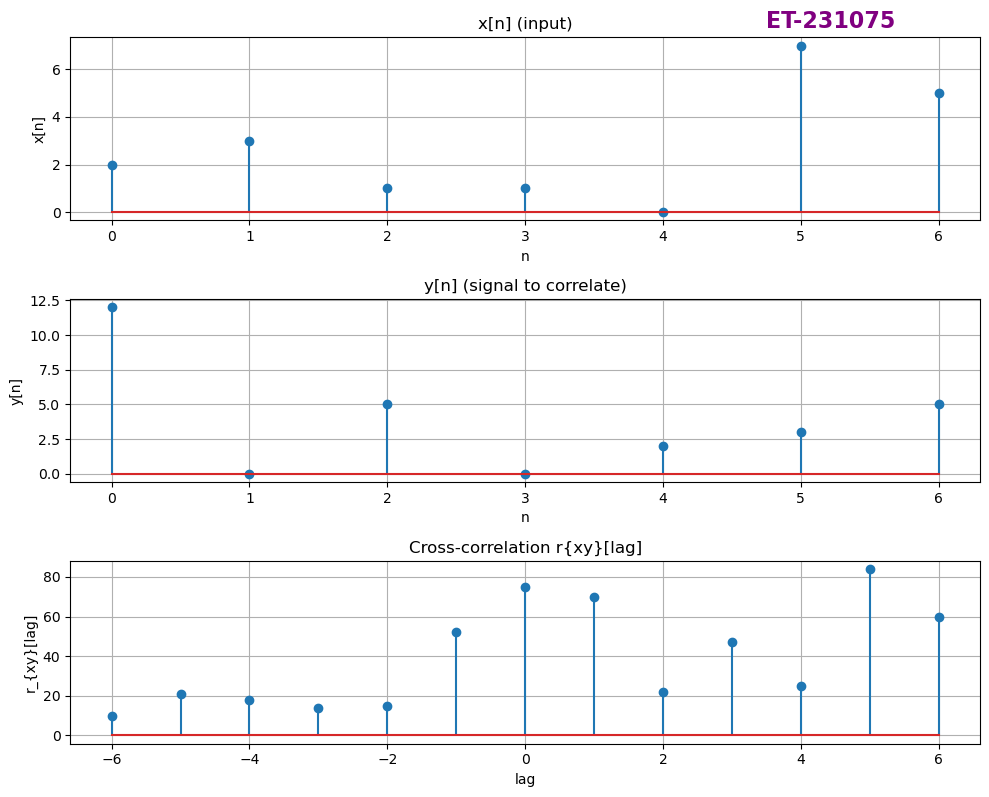

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigfold(x, m):
    # Fold (time-reverse) sequence x and its index vector m.
    y = np.flip(x)
    mf = -np.flip(m)
    return y, mf

def convf(x, n, h, m):
    # Manual convolution (product matrix + diagonal sum) returning Y and index vector K
    start = int(np.min(n) + np.min(m))
    K = np.arange(start, start + len(n) + len(m) - 1)
    YY = np.zeros((len(n), len(m)), dtype=float)
    
    for i in range(len(n)):
        for j in range(len(m)):
            YY[i, j] = x[i] * h[j]
            
    Y = np.zeros(len(K), dtype=float)
    for idx in range(len(K)):
        for i in range(len(n)):
            j = idx - i
            if 0 <= j < len(m):
                Y[idx] += YY[i, j]
                
    return Y, K

x = np.array([2, 3, 1, 1, 0, 7, 5], dtype=float)
n = np.arange(0, len(x))
y = np.array([12, 0, 5, 0, 2, 3, 5], dtype=float)
m = np.arange(0, len(y))

y_fold, mf = sigfold(y, m)
R_xy, K = convf(x, n, y_fold, mf)

# For np.correlate(x, y, 'full'), lags range from -(len(y)-1) .. (len(x)-1)
lags = np.arange(-(len(y) - 1), (len(x) - 1) + 1)
r_numpy = np.correlate(x, y, mode='full') # Direct verification

# Confirm lengths equal
assert len(R_xy) == len(r_numpy) == len(lags)

peak_val = np.max(R_xy)
peak_idx = np.argmax(R_xy)
peak_lag = lags[peak_idx] # corresponds to shift where y best matches x

print("indices n:", n)
print("y(n):", y)
print("indices m:", m)
print()
print("Correlation (manual) length:", len(R_xy))
print("lags (full):", lags)
print("R_xy (manual) =", R_xy.astype(int))
print()
print("np.correlate verification equal?:", np.allclose(R_xy, r_numpy))
print("np.correlate result =", r_numpy.astype(int))
print()
print(f"Peak correlation = {peak_val:.1f} at lag = {peak_lag} (index {peak_idx})")

plt.figure(figsize=(10,8))
# Note: Keeping the ID from the image
plt.figtext(0.90, 0.99, "ET-231075", ha="right", va="top", fontsize=16, color="purple", fontweight='bold')

plt.subplot(3,1,1)
plt.stem(n, x)
plt.title("x[n] (input)")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)

plt.subplot(3,1,2)
plt.stem(m, y)
plt.title("y[n] (signal to correlate)")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)

plt.subplot(3,1,3)
plt.stem(lags, R_xy)
plt.title("Cross-correlation r{xy}[lag]")
plt.xlabel("lag")
plt.ylabel("r_{xy}[lag]")
plt.grid(True)

plt.tight_layout()
plt.show()